# OpenFake 500 benchmark

Notebook nay xem ket qua benchmark 3 model: AI Detection, AI Detection + Physic va UniversalFakeDetect.

Protocol: 500 anh can bang, 250 real + 250 fake, danh gia tai threshold co dinh 0.5, 0.65 va 0.8.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('results/openfake_1k') if Path('results/openfake_1k').exists() else Path('benchmark/results/openfake_1k')
metrics = pd.read_csv(ROOT / 'metrics.csv')
report = json.loads((ROOT / 'report.json').read_text(encoding='utf-8'))

plt.rcParams['font.family'] = ['Arial', 'DejaVu Sans', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

PERCENT_COLS = ['accuracy', 'precision_fake', 'recall_fake', 'f1_fake', 'roc_auc']


def make_metric_view(df):
    view = df.copy()
    view['Threshold'] = view['threshold'].map(lambda value: f'{float(value):.2f}')
    view['Images'] = view['n_images'].astype(int)
    for col in PERCENT_COLS:
        view[col] = (view[col] * 100).map(lambda value: f'{value:.2f}%')
    view = view.rename(columns={
        'model': 'Model',
        'accuracy': 'Accuracy',
        'precision_fake': 'Precision fake',
        'recall_fake': 'Recall fake',
        'f1_fake': 'F1 fake',
        'roc_auc': 'ROC-AUC',
        'true_real_pred_real': 'Real -> Real',
        'true_real_pred_fake': 'Real -> Fake',
        'true_fake_pred_real': 'Fake -> Real',
        'true_fake_pred_fake': 'Fake -> Fake',
    })
    return view[[
        'Model', 'Threshold', 'Images', 'Accuracy', 'Precision fake', 'Recall fake', 'F1 fake', 'ROC-AUC',
        'Real -> Real', 'Real -> Fake', 'Fake -> Real', 'Fake -> Fake'
    ]]


## Metrics


In [2]:
make_metric_view(metrics)


,Model,Threshold,Images,Accuracy,Precision fake,Recall fake,F1 fake,ROC-AUC,Real -> Real,Real -> Fake,Fake -> Real,Fake -> Fake
0,AI Detection,0.50,500,76.60%,77.37%,75.20%,76.27%,85.29%,195,55,62,188
1,AI Detection,0.65,500,76.00%,79.02%,70.80%,74.68%,85.29%,203,47,73,177
2,AI Detection,0.80,500,75.20%,80.58%,66.40%,72.81%,85.29%,210,40,84,166
3,AI Detection + Physic,0.50,500,36.00%,30.77%,22.40%,25.93%,27.41%,124,126,194,56
4,AI Detection + Physic,0.65,500,37.20%,23.77%,11.60%,15.59%,27.41%,157,93,221,29
5,AI Detection + Physic,0.80,500,38.20%,18.95%,7.20%,10.43%,27.41%,173,77,232,18
6,UniversalFakeDetect,0.50,500,48.20%,39.53%,6.80%,11.60%,48.08%,224,26,233,17
7,UniversalFakeDetect,0.65,500,48.40%,38.24%,5.20%,9.15%,48.08%,229,21,237,13
8,UniversalFakeDetect,0.80,500,49.00%,40.00%,4.00%,7.27%,48.08%,235,15,240,10


## Accuracy, precision, recall, F1


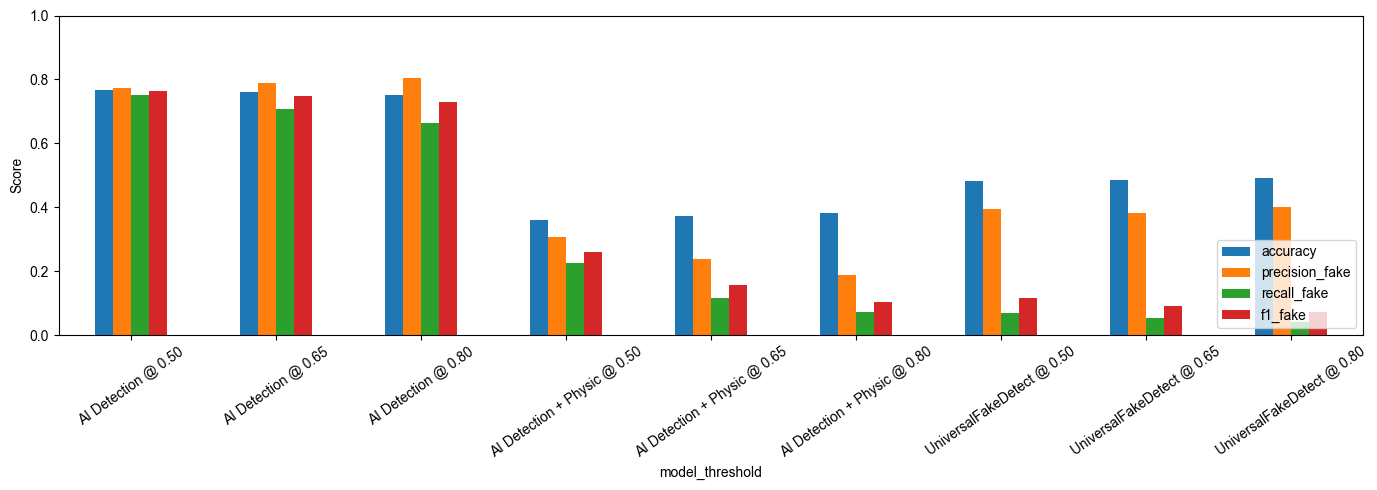

In [3]:
plot_df = metrics.copy()
plot_df['model_threshold'] = plot_df['model'] + ' @ ' + plot_df['threshold'].map(lambda value: f'{float(value):.2f}')
plot_df = plot_df.set_index('model_threshold')[['accuracy', 'precision_fake', 'recall_fake', 'f1_fake']]
ax = plot_df.plot(kind='bar', figsize=(14, 5), ylim=(0, 1), rot=35)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()


## Confusion matrices


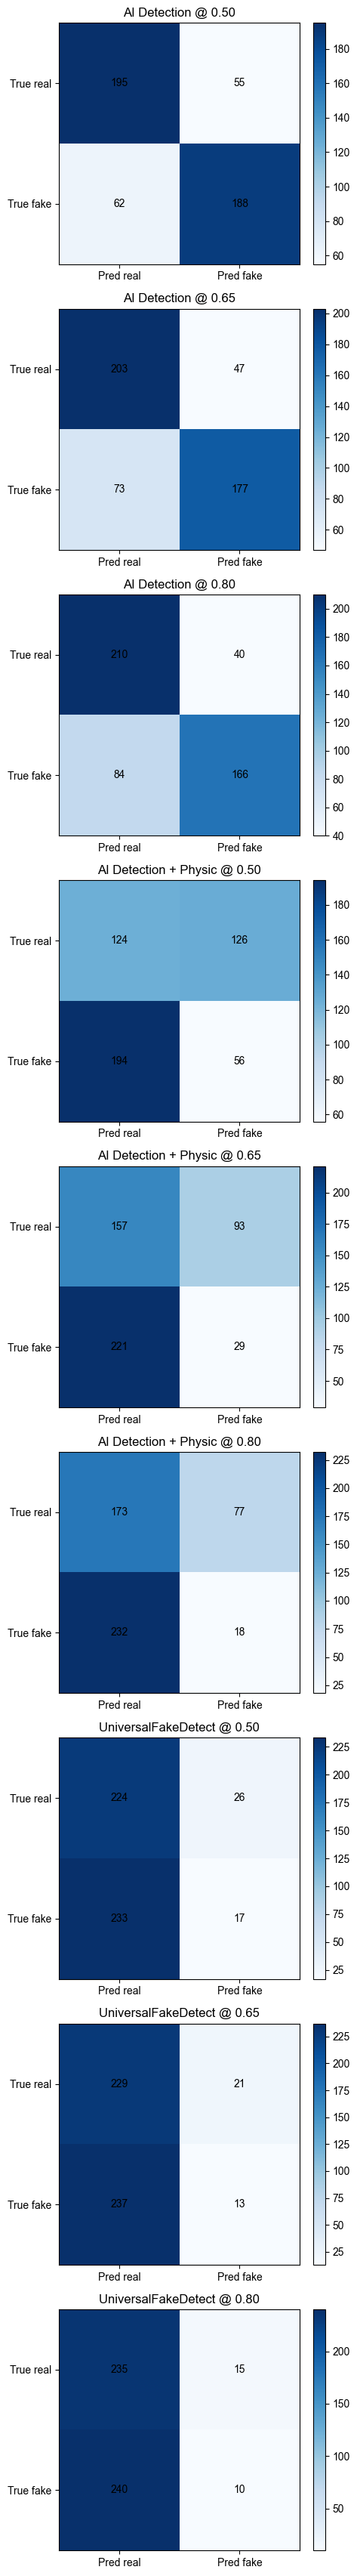

In [4]:
fig, axes = plt.subplots(len(metrics), 1, figsize=(5, 3.8 * len(metrics)))
if len(metrics) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, metrics.iterrows()):
    matrix = [
        [row['true_real_pred_real'], row['true_real_pred_fake']],
        [row['true_fake_pred_real'], row['true_fake_pred_fake']],
    ]
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_title(f"{row['model']} @ {row['threshold']:.2f}")
    ax.set_xticks([0, 1], labels=['Pred real', 'Pred fake'])
    ax.set_yticks([0, 1], labels=['True real', 'True fake'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(matrix[i][j]), ha='center', va='center')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()


## Protocol


In [5]:
report['protocol']


{'models': ['AI Detection', 'AI Detection + Physic', 'UniversalFakeDetect'],
 'thresholds': [0.5, 0.65, 0.8],
 'limit_per_label': 250,
 'total_images': 500,
 'threshold_rule': 'Each model is evaluated at fixed thresholds 0.5, 0.65, and 0.8. No calibration split is used.'}